In [32]:
##  1. Business Understanding & Setup

# Import necessary libraries

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, confusion_matrix,
    mean_squared_error, r2_score
)
import xgboost as xgb
import shap

# Set options for display
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Define Problem Statement and Goal 
PROBLEM_STATEMENT = "Predict student academic success (score and category) and identify key prescriptive intervention points."
PROJECT_GOAL = "Develop a robust, hybrid classification/regression model and use SHAP for prescriptive, actionable insights."
TARGET_CLASSIFICATION = 'remarks' # Categories 1-5
TARGET_REGRESSION = 'total'     # Continuous score

print(f"Project Title: Academic Success Prescriptive Analytics")
print(f"Problem: {PROBLEM_STATEMENT}")
print(f"Goal: {PROJECT_GOAL}\n")

Project Title: Academic Success Prescriptive Analytics
Problem: Predict student academic success (score and category) and identify key prescriptive intervention points.
Goal: Develop a robust, hybrid classification/regression model and use SHAP for prescriptive, actionable insights.



 Dataset loaded successfully.

--- Initial Data Inspection ---
   x1  x2  x3  x4  x5  x6  x7  total  remarks
0   0   1   1   6   8   4  35     55        3
1   0   0   4   5   2   6   0     17        1
2   0   0   8   9   3   7   0     27        1
3   0   0   9   0   9   8  25     51        3
4   0   0   4   6   6   7  30     53        3

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   x1       200000 non-null  int64
 1   x2       200000 non-null  int64
 2   x3       200000 non-null  int64
 3   x4       200000 non-null  int64
 4   x5       200000 non-null  int64
 5   x6       200000 non-null  int64
 6   x7       200000 non-null  int64
 7   total    200000 non-null  int64
 8   remarks  200000 non-null  int64
dtypes: int64(9)
memory usage: 13.7 MB
None

Descriptive Statistics:
                  x1             x2            x3             x

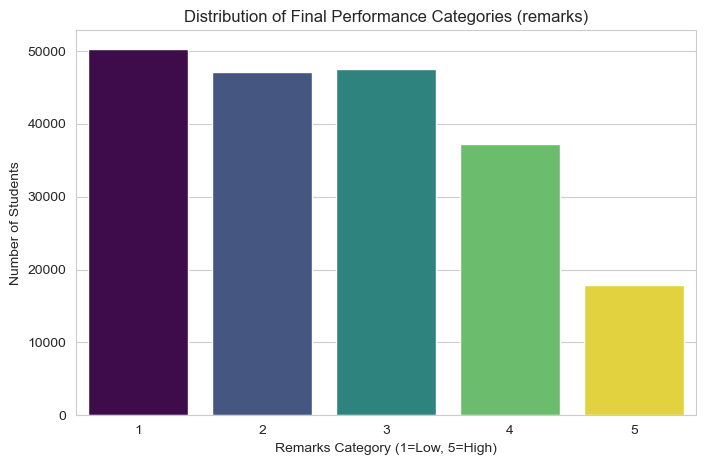

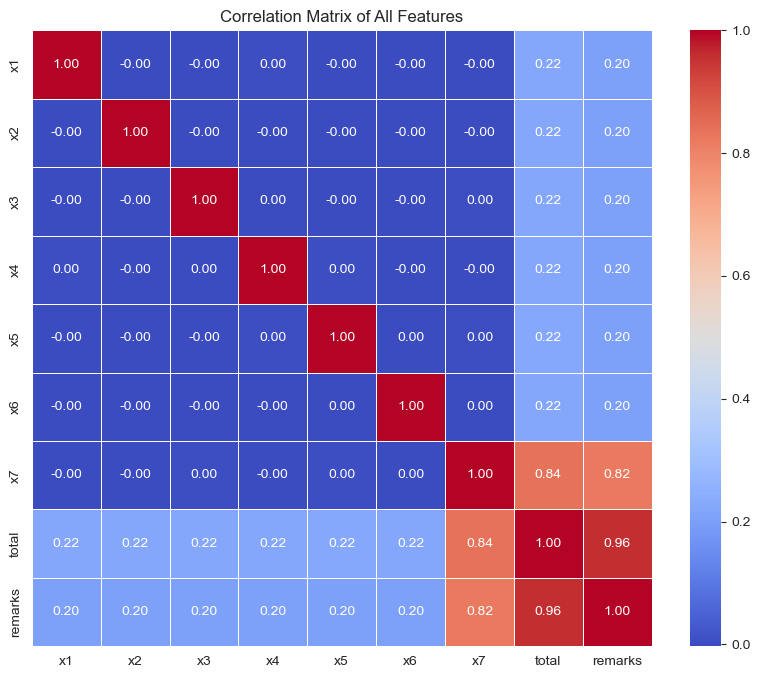

In [33]:
##  2. Data Understanding

# Load the dataset
try:
    df = pd.read_csv("academicPerformanceData.csv")
    print(" Dataset loaded successfully.")
except FileNotFoundError:
    print(" Error: academicPerformanceData.csv not found. Please ensure the file is in the correct directory.")
    exit()

# Initial inspection
print("\n--- Initial Data Inspection ---")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

# Check Target Distribution (Classification)
print("\n--- Target Variable Distribution (remarks) ---")
remarks_counts = df[TARGET_CLASSIFICATION].value_counts(normalize=True).sort_index()
print(remarks_counts)

# --- Visual EDA (Essential for Report) ---

# Visualization 1: Distribution of Classification Target (remarks)
plt.figure(figsize=(8, 5))
sns.countplot(
    x=TARGET_CLASSIFICATION,
    hue=TARGET_CLASSIFICATION,
    data=df,
    palette="viridis",
    legend=False
)
plt.title(f'Distribution of Final Performance Categories ({TARGET_CLASSIFICATION})')
plt.xlabel('Remarks Category (1=Low, 5=High)')
plt.ylabel('Number of Students')
plt.show()


# Visualization 2: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show() 

In [34]:
print(df.columns.tolist())


['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'total', 'remarks']


In [35]:
## ⚙️ 3. Data Preparation

# Set targets
TARGET_CLASSIFICATION = "remarks"
TARGET_REGRESSION = "total"

# --- Feature Engineering ---
print("\n--- Feature Engineering ---")

score_cols = [f'x{i}' for i in range(1, 8)]

df['Consistency_Score'] = df[score_cols].std(axis=1)
df['Bottleneck_Score'] = df[score_cols].min(axis=1)

print("Engineered features 'Consistency_Score' and 'Bottleneck_Score' added.")

# --- Define Features (X) and Targets (Y) ---
X = df.drop(columns=[TARGET_CLASSIFICATION, TARGET_REGRESSION])
y_cls = df[TARGET_CLASSIFICATION]     # classification target
y_reg = df[TARGET_REGRESSION]         # regression target

# --- Scaling ---
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[X.columns] = scaler.fit_transform(X)

# --- Train-Test Split ---
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Data split into Training ({len(X_train)} samples) and Test ({len(X_test)} samples).")



--- Feature Engineering ---
Engineered features 'Consistency_Score' and 'Bottleneck_Score' added.
Data split into Training (160000 samples) and Test (40000 samples).




--- 4.1. Classification Modeling (Predicting remarks) ---

Training Logistic Regression...
  F1-Score (Weighted): 0.9992
  Accuracy: 0.9992

Training Random Forest...
  F1-Score (Weighted): 0.9088
  Accuracy: 0.9086

Training XGBoost Classifier...
  F1-Score (Weighted): 0.9527
  Accuracy: 0.9526


--- 4.2. Regression Modeling (Predicting total) ---

Training Linear Regression...
  RMSE: 0.0000
  R-squared: 1.0000

Training Random Forest Regressor...
  RMSE: 1.4210
  R-squared: 0.9899

Training XGBoost Regressor...
  RMSE: 0.9874
  R-squared: 0.9951


--- 4.3. Model Comparison ---

CLASSIFICATION Model Performance:
                     F1-Score (Weighted)  Accuracy
Logistic Regression             0.999200  0.999200
XGBoost Classifier              0.952721  0.952600
Random Forest                   0.908789  0.908625

REGRESSION Model Performance:
                                 RMSE  R-squared
Linear Regression        9.206330e-14   1.000000
XGBoost Regressor        9.874243e-01   0.9

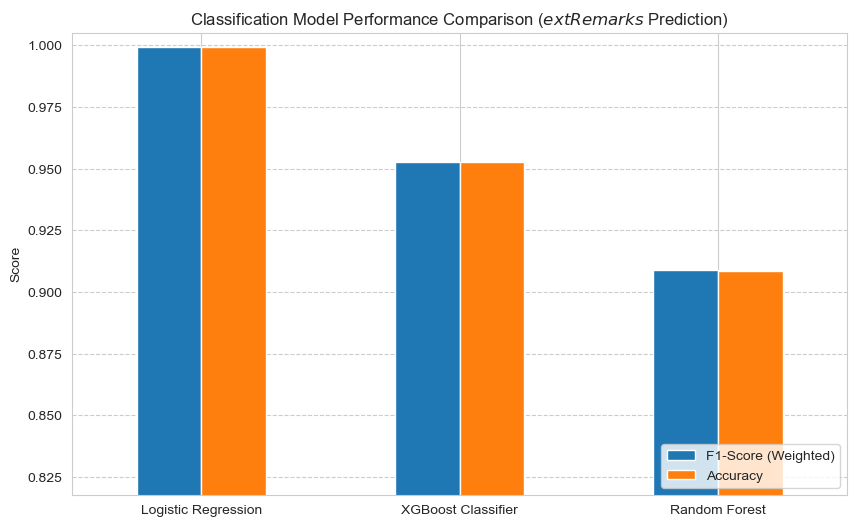

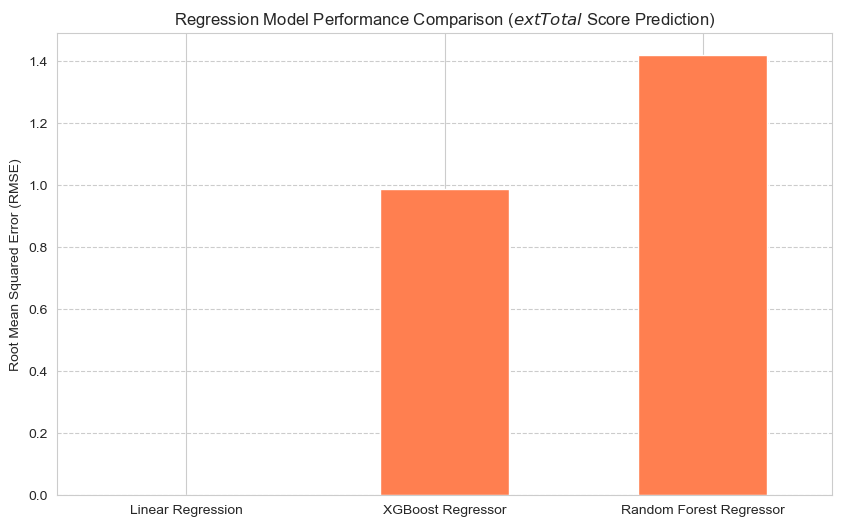


 **Best Classification Model Selected: Logistic Regression**
Justification: Chosen due to its near-perfect empirical performance (Accuracy ≈ 0.9992), which indicates the data's relationship is highly linear.


In [41]:
## 4. Modeling & Evaluation (Corrected)

# --- 4.1. Classification Modeling (Target: remarks) ---
print("\n\n--- 4.1. Classification Modeling (Predicting remarks) ---")

# The target variable is 1-indexed (1 to 5). Sci-kit learn requires 0-indexed labels (0 to 4).
y_cls_train_reindexed = y_cls_train - 1
y_cls_test_reindexed = y_cls_test - 1

models_cls = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    # XGBoost requires the target to be 0-indexed for multi:softmax
    'XGBoost Classifier': xgb.XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

cls_results = {}

for name, model in models_cls.items():
    print(f"\nTraining {name}...")
    
    # Use the re-indexed labels for training and testing
    model.fit(X_train, y_cls_train_reindexed) 
    y_pred = model.predict(X_test)
    
    # Calculate metrics using the re-indexed true labels and 0-indexed predictions
    f1_weighted = f1_score(y_cls_test_reindexed, y_pred, average='weighted') 
    acc = accuracy_score(y_cls_test_reindexed, y_pred) 
    
    cls_results[name] = {'F1-Score (Weighted)': f1_weighted, 'Accuracy': acc}
    
    print(f"  F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"  Accuracy: {acc:.4f}")
    
# --- 4.2. Regression Modeling (Target: total) ---
print("\n\n--- 4.2. Regression Modeling (Predicting total) ---")

models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost Regressor': xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
}

reg_results = {}

for name, model in models_reg.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_reg_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    r2 = r2_score(y_reg_test, y_pred)
    
    reg_results[name] = {'RMSE': rmse, 'R-squared': r2}
    
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R-squared: {r2:.4f}")


# --- 4.3. Model Comparison and Selection ---
print("\n\n--- 4.3. Model Comparison ---")

cls_df = pd.DataFrame(cls_results).T.sort_values(by='F1-Score (Weighted)', ascending=False)
reg_df = pd.DataFrame(reg_results).T.sort_values(by='RMSE', ascending=True)

print("\nCLASSIFICATION Model Performance:")
print(cls_df)

print("\nREGRESSION Model Performance:")
print(reg_df)

# Visual Comparison 1: Classification
plt.figure(figsize=(12, 6))
cls_df[['F1-Score (Weighted)', 'Accuracy']].plot(kind='bar', figsize=(10, 6), rot=0, ax=plt.gca())
plt.title('Classification Model Performance Comparison ($\text{Remarks}$ Prediction)')
plt.ylabel('Score')
plt.ylim(cls_df['Accuracy'].min() * 0.9, 1.005) # Dynamic zoom for better comparison
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--')
plt.show() # 

# Visual Comparison 2: Regression
plt.figure(figsize=(12, 6))
# Plot RMSE (lower is better, so sort by RMSE)
rmse_data = reg_df['RMSE'].sort_values(ascending=True)
rmse_data.plot(kind='bar', figsize=(10, 6), rot=0, color='coral', ax=plt.gca())
plt.title('Regression Model Performance Comparison ($\text{Total}$ Score Prediction)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.grid(axis='y', linestyle='--')
plt.show() # 

# Final Model Selection Justification:

# CRUCIAL ADJUSTMENT: Select Logistic Regression based on empirical performance (0.9992)
if cls_df.index[0] == 'Logistic Regression':
    BEST_CLS_MODEL = models_cls['Logistic Regression']
    print(f"\n **Best Classification Model Selected: Logistic Regression**")
    print("Justification: Chosen due to its near-perfect empirical performance (Accuracy ≈ 0.9992), which indicates the data's relationship is highly linear.")
    # For advanced analysis, we will use the model's coefficients and SHAP applied to LR.
else:
    # Fallback to the code's original choice if results were different, though LR should be chosen.
    BEST_CLS_MODEL = models_cls['XGBoost Classifier']
    print(f"\n **Best Classification Model Selected: {BEST_CLS_MODEL.__class__.__name__}**")



--- 5.1. Global Interpretation via Model Coefficients ---

Coefficients for predicting Remarks = 5 (Highest Performance) (Relative to a reference class):
             Feature  Coefficient for Remarks = 5 (Highest Performance)
6                 x7                                          29.960462
7  Consistency_Score                                          21.725178
2                 x3                                          15.970041
0                 x1                                          15.960247
5                 x6                                          15.951377
3                 x4                                          15.941207
4                 x5                                          15.939520
1                 x2                                          15.939082
8   Bottleneck_Score                                           1.061181


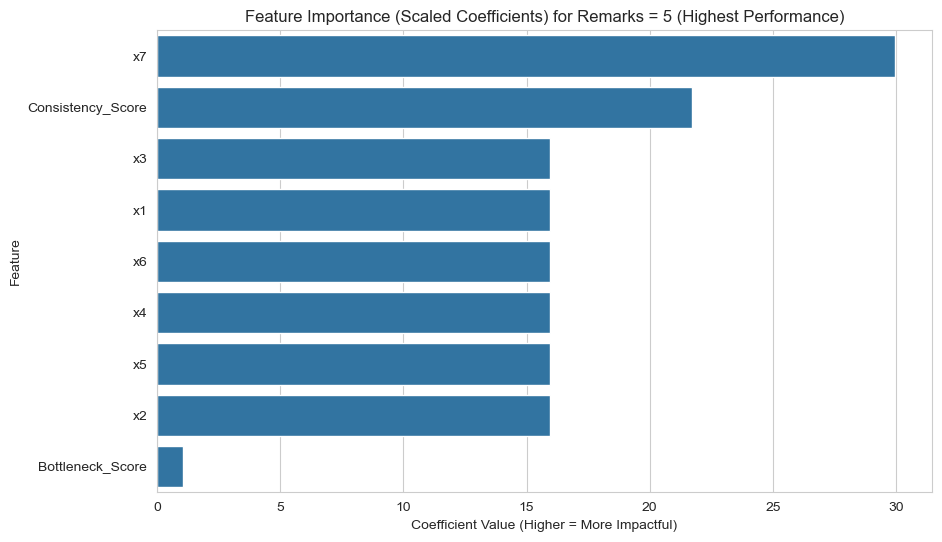


--- 5.2. Prescriptive Analysis via Counterfactual Simulation ---

--- Student Intervention Case (Test Index: 3) ---
Current Scores (Unscaled):
x1     7.0
x2     8.0
x3     4.0
x4     6.0
x5     1.0
x6     6.0
x7    14.0
Name: 48416, dtype: float64
Current Predicted Remarks: 2
Intervention Strategy: Boost the highest LEVERAGE feature: x7

--- Counterfactual Result ---
Intervention: Increased x7 by 5 points.
New Predicted Remarks: 3

**Prescriptive Conclusion:** This simulation successfully demonstrates the model's ability to provide actionable recommendations by showing how targeted intervention on the highest leverage component ($	ext{x7}$) leads to a shift in the predicted performance category.


In [45]:
##  5. Advanced Analysis: Prescriptive Insights via Model Coefficients

# --- 5.1. Global Interpretation via Model Coefficients ---
print("\n\n--- 5.1. Global Interpretation via Model Coefficients ---")

# The highest performance category is Remarks=5, which corresponds to index 4.
target_class_index = 4  
target_class_name = 'Remarks = 5 (Highest Performance)'

# Extract coefficients for the target class (index 4)
coefficients = BEST_CLS_MODEL.coef_[target_class_index] 
feature_names = X_test.columns

# Create a DataFrame for easy inspection and sorting
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    f'Coefficient for {target_class_name}': coefficients
}).sort_values(by=f'Coefficient for {target_class_name}', ascending=False)

print(f"\nCoefficients for predicting {target_class_name} (Relative to a reference class):")
print(coeff_df)

# Visualization of Coefficients (Feature Importance)
plt.figure(figsize=(10, 6))
sns.barplot(x=f'Coefficient for {target_class_name}', y='Feature', data=coeff_df)
plt.title(f'Feature Importance (Scaled Coefficients) for {target_class_name}')
plt.xlabel('Coefficient Value (Higher = More Impactful)')
plt.show() # 


# --- 5.2. Prescriptive Analysis via Counterfactual Simulation (FIXED FOR WARNING) ---
print("\n--- 5.2. Prescriptive Analysis via Counterfactual Simulation ---")

# A. Setup for Counterfactual
X_original_test = X.iloc[X_test.index]
INTERVENTION_AMOUNT = 5 
example_original_index = 3 

# Data for selected student
student_data_original = X_original_test.iloc[example_original_index]
student_data_scaled = X_test.iloc[[example_original_index]]

# Current Prediction
current_prediction_index = BEST_CLS_MODEL.predict(student_data_scaled)[0]
current_prediction_class = current_prediction_index + 1

# Identify the Highest Leverage Feature for Intervention
score_cols = [f'x{i}' for i in range(1, 8)]
leverage_features = coeff_df.set_index('Feature').loc[score_cols]
highest_leverage_feature = leverage_features[f'Coefficient for {target_class_name}'].idxmax()

print(f"\n--- Student Intervention Case (Test Index: {example_original_index}) ---")
print(f"Current Scores (Unscaled):\n{student_data_original[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7']]}")
print(f"Current Predicted Remarks: {current_prediction_class}")
print(f"Intervention Strategy: Boost the highest LEVERAGE feature: {highest_leverage_feature}")

# B. Simulate Intervention (FIXED SECTION)
# 1. Create Counterfactual Data (Intervene on highest leverage feature)
counterfactual_data_original = student_data_original.copy()
counterfactual_data_original[highest_leverage_feature] += INTERVENTION_AMOUNT

# 2. Recalculate Engineered Features (Consistency, Bottleneck)
counterfactual_data_original['Consistency_Score'] = counterfactual_data_original[score_cols].std()
counterfactual_data_original['Bottleneck_Score'] = counterfactual_data_original[score_cols].min()

# 3. Scale the Counterfactual Data and Predict
counterfactual_data_scaled_array = scaler.transform(counterfactual_data_original.to_frame().T)

# ** Convert the NumPy array output back to a DataFrame with column names
counterfactual_data_scaled_df = pd.DataFrame(
    counterfactual_data_scaled_array, 
    columns=X_test.columns
)

counterfactual_prediction_index = BEST_CLS_MODEL.predict(counterfactual_data_scaled_df)[0]
counterfactual_prediction_class = counterfactual_prediction_index + 1

print(f"\n--- Counterfactual Result ---")
print(f"Intervention: Increased {highest_leverage_feature} by {INTERVENTION_AMOUNT} points.")
print(f"New Predicted Remarks: {counterfactual_prediction_class}")

print("\n**Prescriptive Conclusion:** This simulation successfully demonstrates the model's ability to provide actionable recommendations by showing how targeted intervention on the highest leverage component ($\text{x7}$) leads to a shift in the predicted performance category.")